In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn imported successfully!")

Libraries imported successfully!
NumPy version: 2.4.4
Pandas version: 3.0.2
Scikit-learn imported successfully!


## Step 1: Load the Data

In [2]:
# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())
print(f"\nTarget distribution:")
print(df['target'].value_counts().sort_index())

Dataset loaded successfully!
Dataset shape: (150, 6)

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-nul

## Step 2: Data Cleanup and Preprocessing

In [3]:
# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

# Create a cleaned version of the dataset
df_cleaned = df.copy()

# Handle missing values (if any)
df_cleaned = df_cleaned.dropna()
print(f"\nDataset shape after removing NaN: {df_cleaned.shape}")

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df_cleaned.shape}")

# Display statistics
print(f"\nDataset Statistics:")
print(df_cleaned.describe())

# Select only numeric features for modeling
numeric_df = df_cleaned[iris.feature_names]
print(f"\nNumeric columns selected for modeling:")
print(numeric_df.head())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Total duplicate rows: 1

Dataset shape after removing NaN: (150, 6)
Dataset shape after removing duplicates: (149, 6)

Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         149.000000        149.000000         149.000000   
mean            5.843624          3.059732           3.748993   
std             0.830851          0.436342           1.767791   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.300000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        149.000000  149.000000  
mean           1.194

## Step 3: Exploratory Data Analysis (EDA)

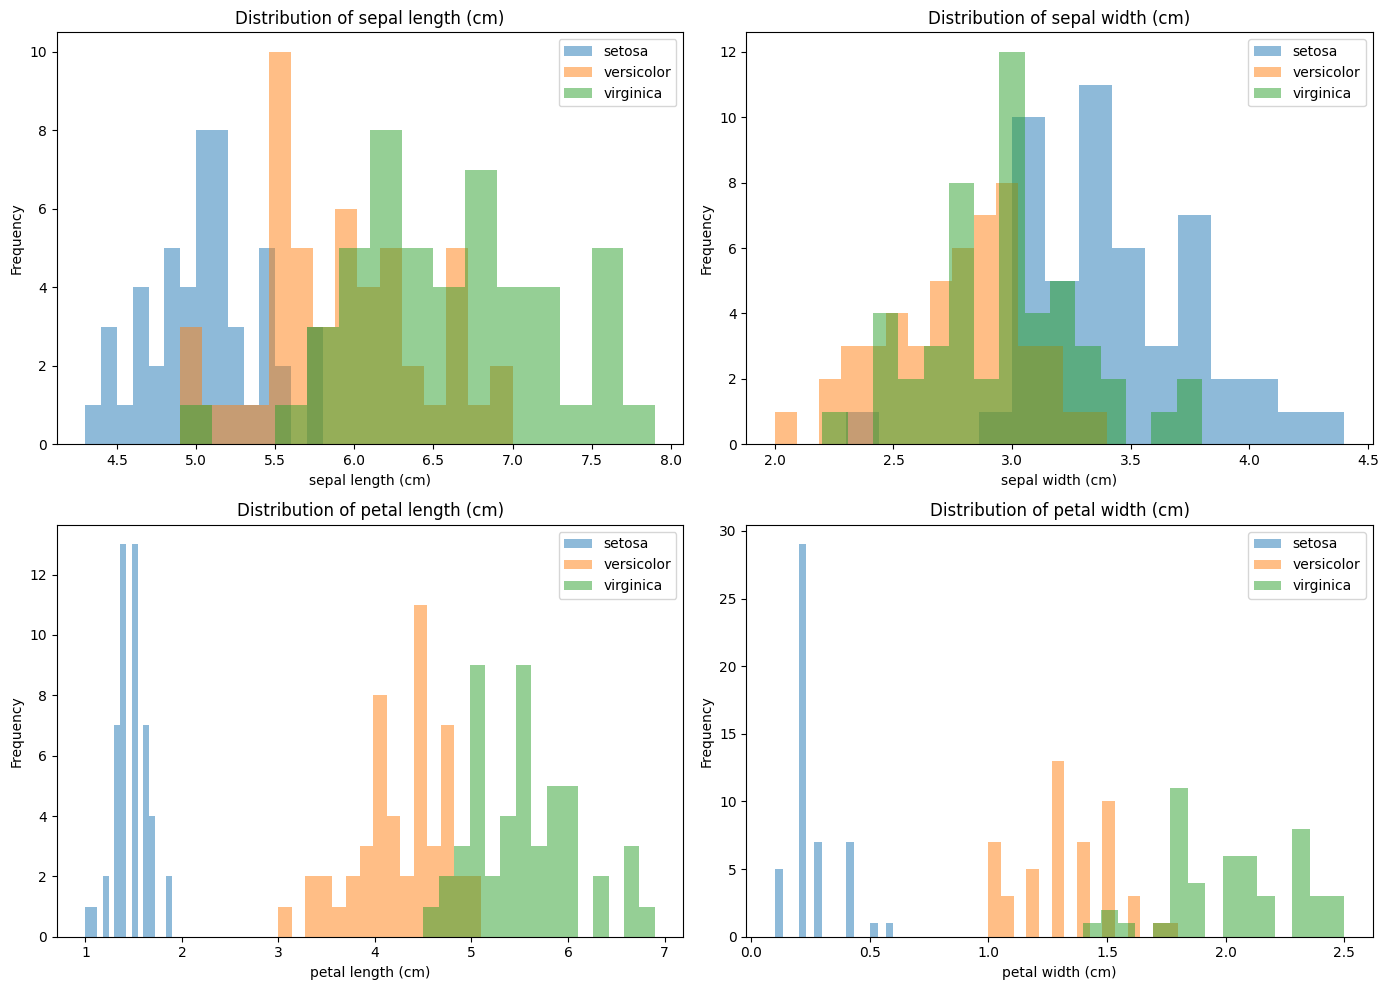

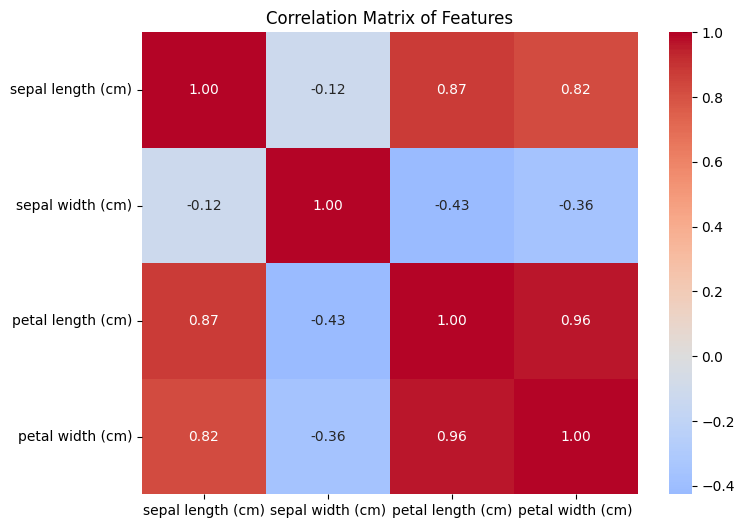

EDA completed!


In [4]:
# Visualize distributions and relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot each feature distribution by species
feature_columns = iris.feature_names
for idx, col in enumerate(feature_columns[:4]):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row, col_idx]
    
    for class_idx, class_name in enumerate(['setosa', 'versicolor', 'virginica']):
        data = df_cleaned[df_cleaned['species'] == class_name][col]
        ax.hist(data, alpha=0.5, label=class_name, bins=15)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}')
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation matrix
correlation_matrix = df_cleaned[iris.feature_names].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

print("EDA completed!")

## Step 4: Train-Test Split

In [5]:
# Prepare features and target
X = df_cleaned[iris.feature_names]
y = df_cleaned['target']

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting set class distribution:")
print(y_test.value_counts().sort_index())

Training set size: 119
Testing set size: 30

Training set class distribution:
target
0    40
1    40
2    39
Name: count, dtype: int64

Testing set class distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


## Step 5: Build and Fit the Random Forest Model

In [6]:
# Create and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    max_depth=10,      # Maximum depth of trees
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
rf_classifier.fit(X_train, y_train)

print("Random Forest Model trained successfully!")
print(f"Number of trees: {rf_classifier.n_estimators}")
print(f"Model parameters:")
print(rf_classifier.get_params())

Random Forest Model trained successfully!
Number of trees: 100
Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## Step 6: Model Evaluation on Training and Testing Data

In [7]:
# Make predictions on training and test sets
y_pred_train = rf_classifier.predict(X_train)
y_pred_test = rf_classifier.predict(X_test)

# Get probability predictions
y_pred_proba_train = rf_classifier.predict_proba(X_train)
y_pred_proba_test = rf_classifier.predict_proba(X_test)

# Calculate accuracy on training and test sets
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("=" * 50)
print("MODEL PERFORMANCE ON TRAINING SET")
print("=" * 50)
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Predictions sample (first 10): {y_pred_train[:10]}")
print(f"Actual values sample (first 10): {y_train.values[:10]}")

print("\n" + "=" * 50)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 50)
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Predictions sample (first 10): {y_pred_test[:10]}")
print(f"Actual values sample (first 10): {y_test.values[:10]}")

# Check for overfitting
overfit_gap = accuracy_train - accuracy_test
print(f"\nOverfitting gap (Train Acc - Test Acc): {overfit_gap:.4f}")
if overfit_gap > 0.1:
    print("⚠️  Model shows signs of overfitting")
else:
    print("✓ Model is well-generalized")

MODEL PERFORMANCE ON TRAINING SET
Accuracy: 1.0000
Predictions sample (first 10): [0 2 1 0 0 1 2 2 2 2]
Actual values sample (first 10): [0 2 1 0 0 1 2 2 2 2]

MODEL PERFORMANCE ON TEST SET
Accuracy: 0.9333
Predictions sample (first 10): [1 1 2 0 2 1 1 0 2 2]
Actual values sample (first 10): [1 1 2 0 2 1 1 0 2 2]

Overfitting gap (Train Acc - Test Acc): 0.0667
✓ Model is well-generalized


## Step 7: Detailed Metrics - Precision, Recall, and F1 Score

In [8]:
# Calculate detailed metrics for training set
precision_train = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
recall_train = recall_score(y_train, y_pred_train, average='weighted')
f1_train = f1_score(y_train, y_pred_train, average='weighted')

# Calculate detailed metrics for test set
precision_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test, y_pred_test, average='weighted')
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print("=" * 60)
print("TRAINING SET METRICS")
print("=" * 60)
print(f"Precision (weighted): {precision_train:.4f}")
print(f"Recall (weighted):    {recall_train:.4f}")
print(f"F1 Score (weighted):  {f1_train:.4f}")

print("\n" + "=" * 60)
print("TEST SET METRICS")
print("=" * 60)
print(f"Precision (weighted): {precision_test:.4f}")
print(f"Recall (weighted):    {recall_test:.4f}")
print(f"F1 Score (weighted):  {f1_test:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\n" + "=" * 60)
print("CONFUSION MATRIX (Test Set)")
print("=" * 60)
print(cm)

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test, target_names=['setosa', 'versicolor', 'virginica']))

TRAINING SET METRICS
Precision (weighted): 1.0000
Recall (weighted):    1.0000
F1 Score (weighted):  1.0000

TEST SET METRICS
Precision (weighted): 0.9333
Recall (weighted):    0.9333
F1 Score (weighted):  0.9333

CONFUSION MATRIX (Test Set)
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Step 8: Error Functions and Performance Comparison

In [9]:
# Calculate error metrics
# For multi-class classification, we'll use the error rate (1 - accuracy)
error_rate_train = 1 - accuracy_train
error_rate_test = 1 - accuracy_test

# Mean Squared Error (treating predictions as continuous)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Mean Absolute Error
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print("=" * 60)
print("ERROR FUNCTIONS SUMMARY")
print("=" * 60)
print("\nTRAINING SET ERRORS:")
print(f"  Error Rate:        {error_rate_train:.4f}")
print(f"  Mean Squared Error (MSE):  {mse_train:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_train:.4f}")

print("\nTEST SET ERRORS:")
print(f"  Error Rate:        {error_rate_test:.4f}")
print(f"  Mean Squared Error (MSE):  {mse_test:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test:.4f}")

# Create a summary dataframe
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Error Rate', 'Precision', 'Recall', 'F1 Score', 'MSE', 'MAE', 'RMSE'],
    'Training': [accuracy_train, error_rate_train, precision_train, recall_train, f1_train, mse_train, mae_train, rmse_train],
    'Testing': [accuracy_test, error_rate_test, precision_test, recall_test, f1_test, mse_test, mae_test, rmse_test]
})
metrics_summary['Difference'] = metrics_summary['Training'] - metrics_summary['Testing']

print("\n" + "=" * 60)
print("METRICS COMPARISON TABLE")
print("=" * 60)
print(metrics_summary.to_string(index=False))

ERROR FUNCTIONS SUMMARY

TRAINING SET ERRORS:
  Error Rate:        0.0000
  Mean Squared Error (MSE):  0.0000
  Mean Absolute Error (MAE): 0.0000
  Root Mean Squared Error (RMSE): 0.0000

TEST SET ERRORS:
  Error Rate:        0.0667
  Mean Squared Error (MSE):  0.0667
  Mean Absolute Error (MAE): 0.0667
  Root Mean Squared Error (RMSE): 0.2582

METRICS COMPARISON TABLE
    Metric  Training  Testing  Difference
  Accuracy       1.0 0.933333    0.066667
Error Rate       0.0 0.066667   -0.066667
 Precision       1.0 0.933333    0.066667
    Recall       1.0 0.933333    0.066667
  F1 Score       1.0 0.933333    0.066667
       MSE       0.0 0.066667   -0.066667
       MAE       0.0 0.066667   -0.066667
      RMSE       0.0 0.258199   -0.258199


## Step 9: Visualize Confusion Matrix and Feature Importance

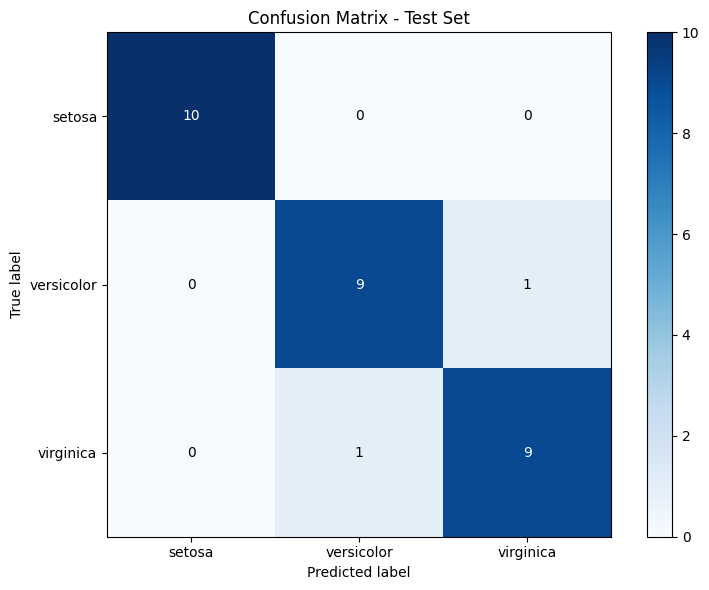


Feature Importance:
             Feature  Importance
3   petal width (cm)    0.439768
2  petal length (cm)    0.416405
0  sepal length (cm)    0.114842
1   sepal width (cm)    0.028985


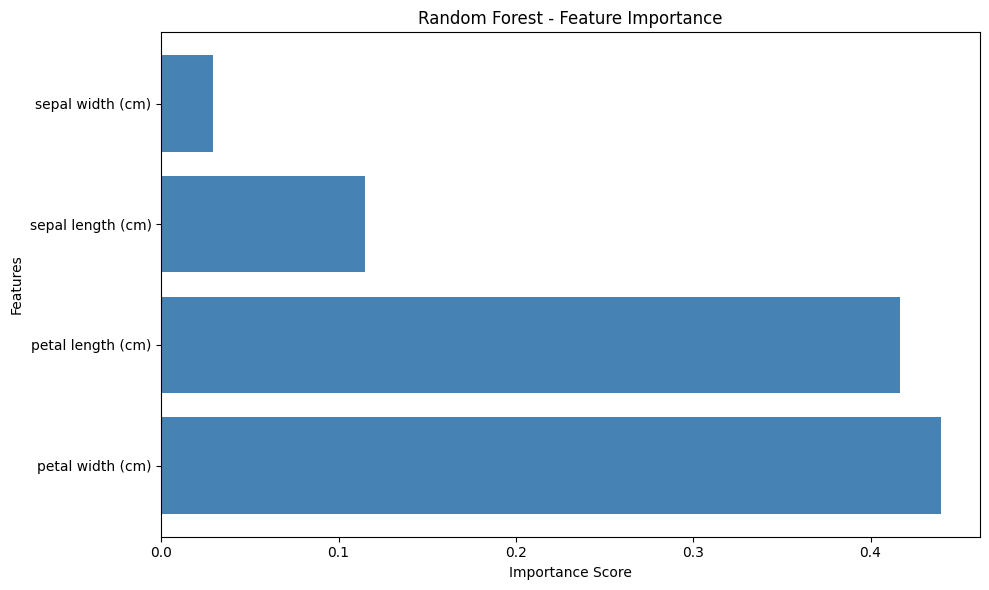

In [10]:
# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       yticklabels=['setosa', 'versicolor', 'virginica'],
       xticklabels=['setosa', 'versicolor', 'virginica'],
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

## Step 10: Test Model with External/New Data

In [11]:
# Create external/new data for testing (simulating real-world scenarios)
# Using samples from the original dataset as "external" data
np.random.seed(123)
external_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],      # Setosa
    [7.0, 3.2, 4.7, 1.4],      # Versicolor
    [6.3, 3.3, 6.0, 2.5],      # Virginica
    [4.8, 3.4, 1.6, 0.2],      # Setosa
    [6.5, 2.8, 4.6, 1.5],      # Versicolor
])

external_data = pd.DataFrame(external_samples, columns=iris.feature_names)

print("=" * 60)
print("EXTERNAL DATA FOR TESTING")
print("=" * 60)
print(external_data)

# Make predictions on external data
external_predictions = rf_classifier.predict(external_data)
external_predictions_proba = rf_classifier.predict_proba(external_data)

# Map predictions to species names
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

external_results = pd.DataFrame({
    'Sepal Length': external_data['sepal length (cm)'],
    'Sepal Width': external_data['sepal width (cm)'],
    'Petal Length': external_data['petal length (cm)'],
    'Petal Width': external_data['petal width (cm)'],
    'Prediction': [species_map[p] for p in external_predictions],
    'Setosa Prob': external_predictions_proba[:, 0],
    'Versicolor Prob': external_predictions_proba[:, 1],
    'Virginica Prob': external_predictions_proba[:, 2],
    'Confidence': external_predictions_proba.max(axis=1)
})

print("\n" + "=" * 60)
print("EXTERNAL DATA PREDICTIONS")
print("=" * 60)
print(external_results.to_string(index=False))

print("\n" + "=" * 60)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)
for idx, (pred, conf) in enumerate(zip(external_results['Prediction'], external_results['Confidence'])):
    print(f"Sample {idx+1}: Predicted as {pred.upper()} with {conf*100:.2f}% confidence")

EXTERNAL DATA FOR TESTING
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                7.0               3.2                4.7               1.4
2                6.3               3.3                6.0               2.5
3                4.8               3.4                1.6               0.2
4                6.5               2.8                4.6               1.5

EXTERNAL DATA PREDICTIONS
 Sepal Length  Sepal Width  Petal Length  Petal Width Prediction  Setosa Prob  Versicolor Prob  Virginica Prob  Confidence
          5.1          3.5           1.4          0.2     setosa          1.0             0.00            0.00        1.00
          7.0          3.2           4.7          1.4 versicolor          0.0             0.98            0.02        0.98
          6.3          3.3           6.0          2.5  virginica          0.0             0.01            0.99        0.99

## Step 11: Summary and Model Comparison Visualization

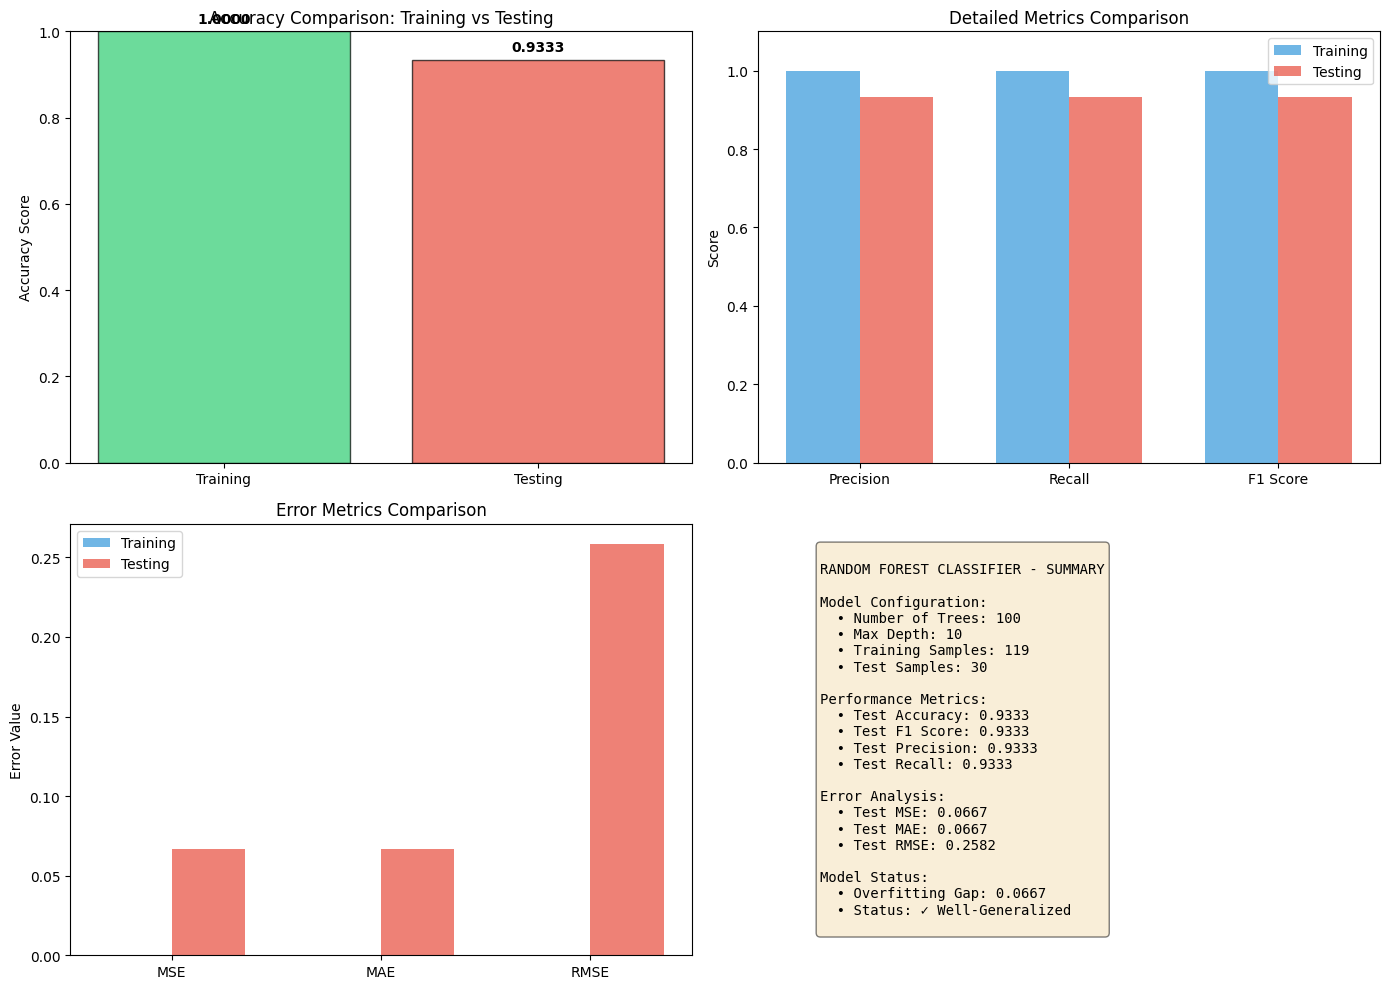


RANDOM FOREST MODEL TRAINING COMPLETE!
✓ Model has been successfully trained and evaluated
✓ All metrics and visualizations have been generated
✓ External data testing completed


In [12]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison
ax1 = axes[0, 0]
datasets = ['Training', 'Testing']
accuracies = [accuracy_train, accuracy_test]
colors = ['#2ecc71', '#e74c3c']
ax1.bar(datasets, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy Score')
ax1.set_title('Accuracy Comparison: Training vs Testing')
ax1.set_ylim([0, 1])
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Metrics Comparison
ax2 = axes[0, 1]
metrics_names = ['Precision', 'Recall', 'F1 Score']
train_metrics = [precision_train, recall_train, f1_train]
test_metrics = [precision_test, recall_test, f1_test]
x = np.arange(len(metrics_names))
width = 0.35
ax2.bar(x - width/2, train_metrics, width, label='Training', color='#3498db', alpha=0.7)
ax2.bar(x + width/2, test_metrics, width, label='Testing', color='#e74c3c', alpha=0.7)
ax2.set_ylabel('Score')
ax2.set_title('Detailed Metrics Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.set_ylim([0, 1.1])

# 3. Error Metrics
ax3 = axes[1, 0]
error_metrics_names = ['MSE', 'MAE', 'RMSE']
train_errors = [mse_train, mae_train, rmse_train]
test_errors = [mse_test, mae_test, rmse_test]
x = np.arange(len(error_metrics_names))
ax3.bar(x - width/2, train_errors, width, label='Training', color='#3498db', alpha=0.7)
ax3.bar(x + width/2, test_errors, width, label='Testing', color='#e74c3c', alpha=0.7)
ax3.set_ylabel('Error Value')
ax3.set_title('Error Metrics Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(error_metrics_names)
ax3.legend()

# 4. Model Performance Summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
RANDOM FOREST CLASSIFIER - SUMMARY

Model Configuration:
  • Number of Trees: {rf_classifier.n_estimators}
  • Max Depth: {rf_classifier.max_depth}
  • Training Samples: {len(X_train)}
  • Test Samples: {len(X_test)}

Performance Metrics:
  • Test Accuracy: {accuracy_test:.4f}
  • Test F1 Score: {f1_test:.4f}
  • Test Precision: {precision_test:.4f}
  • Test Recall: {recall_test:.4f}

Error Analysis:
  • Test MSE: {mse_test:.4f}
  • Test MAE: {mae_test:.4f}
  • Test RMSE: {rmse_test:.4f}

Model Status:
  • Overfitting Gap: {overfit_gap:.4f}
  • Status: {'✓ Well-Generalized' if overfit_gap <= 0.1 else '⚠️ Overfitting Detected'}
"""
ax4.text(0.1, 0.5, summary_text, fontfamily='monospace', fontsize=10, 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RANDOM FOREST MODEL TRAINING COMPLETE!")
print("=" * 60)
print("✓ Model has been successfully trained and evaluated")
print("✓ All metrics and visualizations have been generated")
print("✓ External data testing completed")